# 📰 NewsBot Intelligence System
## ITAI2373 — Mid-Term Group Project



---
## Step 1 — Install & Import All Required Libraries

In [1]:
# Install all required libraries
!pip install nltk spacy scikit-learn pandas matplotlib seaborn wordcloud textblob -q
!python -m spacy download en_core_web_sm -q

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('maxent_ne_chunker', quiet=True)
nltk.download('maxent_ne_chunker_tab', quiet=True)
nltk.download('words', quiet=True)

print('✅ All libraries installed successfully!')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 178.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All libraries installed successfully!


In [2]:
# ── IMPORTS — run this after any runtime restart
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, warnings
warnings.filterwarnings('ignore')

import nltk
import spacy
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, ne_chunk
from nltk.tree import Tree

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)
from sklearn.pipeline import Pipeline
from textblob import TextBlob
from wordcloud import WordCloud
from collections import Counter

nlp = spacy.load('en_core_web_sm')
plt.style.use('seaborn-v0_8-darkgrid')
print('✅ All imports successful!')

✅ All imports successful!


---
## Step 2 — Dataset Acquisition


In [3]:
# Method 2: Direct Download — Upload your CSV file to Google Colab
from google.colab import files
print('Click Choose Files and upload BBC_News_Train.csv ...')
uploaded = files.upload()
print('✅ File uploaded!')

Click Choose Files and upload BBC_News_Train.csv ...


Saving BBC News Train.csv to BBC News Train.csv
✅ File uploaded!


---
## Step 3 — Prepare Your Dataset


In [4]:
# Data preparation template
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/BBC News Train.csv')

# 1. Examine your dataset
print('Dataset Info:')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print('\nFirst few rows:')
print(df.head())

# 2. Identify text and category columns
# Adjust these column names based on your dataset
text_column = 'Text'          # BBC dataset uses 'Text'
category_column = 'Category'  # BBC dataset uses 'Category'

# 3. Check for missing values
print('\nMissing values:')
print(df.isnull().sum())

# 4. Remove rows with missing text or categories
df_clean = df.dropna(subset=[text_column, category_column])

# 5. Check category distribution
print('\nCategory distribution:')
print(df_clean[category_column].value_counts())

# 6. Sample if dataset is too large (keep under 2000 for Colab)
if len(df_clean) > 2000:
    df_final = df_clean.sample(n=2000, random_state=42)
    print(f'\nSampled dataset to {len(df_final)} rows')
else:
    df_final = df_clean

# 7. Rename columns for consistency
df_final = df_final.rename(columns={
    text_column: 'content',
    category_column: 'category'
})

# 8. Save prepared dataset
df_final.to_csv('newsbot_dataset.csv', index=False)
print("\n✅ Dataset prepared and saved as 'newsbot_dataset.csv'")
print(f'Final dataset shape: {df_final.shape}')
print(f'Categories: {df_final["category"].unique()}')

Dataset Info:
Shape: (1490, 3)
Columns: ['ArticleId', 'Text', 'Category']

First few rows:
   ArticleId                                               Text  Category
0       1833  worldcom ex-boss launches defence lawyers defe...  business
1        154  german business confidence slides german busin...  business
2       1101  bbc poll indicates economic gloom citizens in ...  business
3       1976  lifestyle  governs mobile choice  faster  bett...      tech
4        917  enron bosses in $168m payout eighteen former e...  business

Missing values:
ArticleId    0
Text         0
Category     0
dtype: int64

Category distribution:
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64

✅ Dataset prepared and saved as 'newsbot_dataset.csv'
Final dataset shape: (1490, 3)
Categories: ['business' 'tech' 'politics' 'sport' 'entertainment']


---
#  MODULE 1: Real-World NLP Application Context

## Business Case & Application Description

**NewsBot Intelligence System** is an automated news analysis platform that processes, categorizes, and extracts insights from large volumes of news articles using NLP.

### Industry Context & Use Cases
- **Google News** — auto-categorizes millions of articles daily
- **Financial Firms** — monitor market-relevant news for investment decisions
- **Media Companies** — track competitor coverage and editorial trends
- **Researchers** — analyze public opinion patterns across categories

### Target Users & Value Proposition
| Target User | Problem | NewsBot Solution |
|---|---|---|
| News Editors | Manual article sorting takes hours | Auto-categorize in milliseconds |
| Financial Analysts | Can't read all market news | Instant sentiment + entity alerts |
| PR Managers | Miss brand mentions | Real-time entity tracking |
| Researchers | Can't analyze thousands of articles | Automated pattern extraction |

In [5]:
# MODULE 1: Load prepared dataset and explore
df = pd.read_csv('newsbot_dataset.csv')

print('=' * 55)
print('       NEWSBOT — MODULE 1 DATASET OVERVIEW')
print('=' * 55)
print(f'  Total Articles  : {len(df)}')
print(f'  Columns         : {df.columns.tolist()}')
print(f'  Missing Values  : {df.isnull().sum().sum()}')
print(f'  Avg Article Len : {df["content"].apply(len).mean():.0f} characters')
print()
print('  Articles per Category:')
print(df['category'].value_counts().to_string())
print('=' * 55)
print('\n Sample Article (first 300 chars):')
print(df['content'].iloc[0][:300], '...')

       NEWSBOT — MODULE 1 DATASET OVERVIEW
  Total Articles  : 1490
  Columns         : ['ArticleId', 'content', 'category']
  Missing Values  : 0
  Avg Article Len : 2233 characters

  Articles per Category:
category
sport            346
business         336
politics         274
entertainment    273
tech             261

 Sample Article (first 300 chars):
worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.  cynthia cooper  worldcom s ex-head of internal accounting  alerted directors to irregular accounting practices at th ...


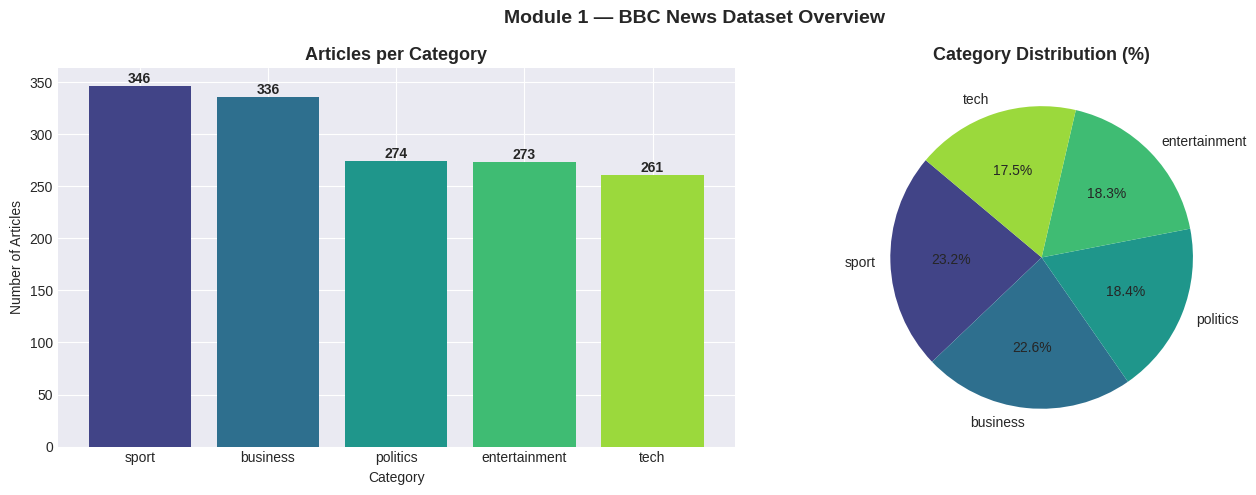

✅ Module 1 Complete!


In [6]:
# MODULE 1: Category Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_counts = df['category'].value_counts()
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(cat_counts)))

bars = axes[0].bar(cat_counts.index, cat_counts.values, color=colors)
axes[0].set_title('Articles per Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Articles')
for bar, val in zip(bars, cat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3, str(val), ha='center', fontsize=10, fontweight='bold')

axes[1].pie(cat_counts.values, labels=cat_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title('Category Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Module 1 — BBC News Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('module1_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Module 1 Complete!')

---
# MODULE 2: Text Preprocessing Pipeline

In [7]:
# MODULE 2: Full Text Preprocessing Pipeline
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Complete text preprocessing pipeline:
    1. Lowercase
    2. Remove URLs, special chars, numbers
    3. Tokenization
    4. Stop word removal
    5. Lemmatization
    Handles edge cases: empty strings, non-ASCII
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

print('⏳ Preprocessing all articles...')
df['processed_text']    = df['content'].apply(preprocess_text)
df['tokens_before']     = df['content'].apply(lambda x: len(x.split()))
df['tokens_after']      = df['processed_text'].apply(lambda x: len(x.split()))
reduction = (1 - df['tokens_after'].mean()/df['tokens_before'].mean()) * 100

print('✅ Preprocessing complete!')
print(f'\n  Avg tokens BEFORE : {df["tokens_before"].mean():.0f}')
print(f'  Avg tokens AFTER  : {df["tokens_after"].mean():.0f}')
print(f'  Reduction         : {reduction:.1f}%')
print('\n BEFORE preprocessing:')
print(df['content'].iloc[0][:200])
print('\n AFTER preprocessing:')
print(df['processed_text'].iloc[0][:200])

⏳ Preprocessing all articles...
✅ Preprocessing complete!

  Avg tokens BEFORE : 385
  Avg tokens AFTER  : 207
  Reduction         : 46.1%

 BEFORE preprocessing:
worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.  cynthia cooper  

 AFTER preprocessing:
worldcom exboss launch defence lawyer defending former worldcom chief bernie ebbers battery fraud charge called company whistleblower first witness cynthia cooper worldcom exhead internal accounting a


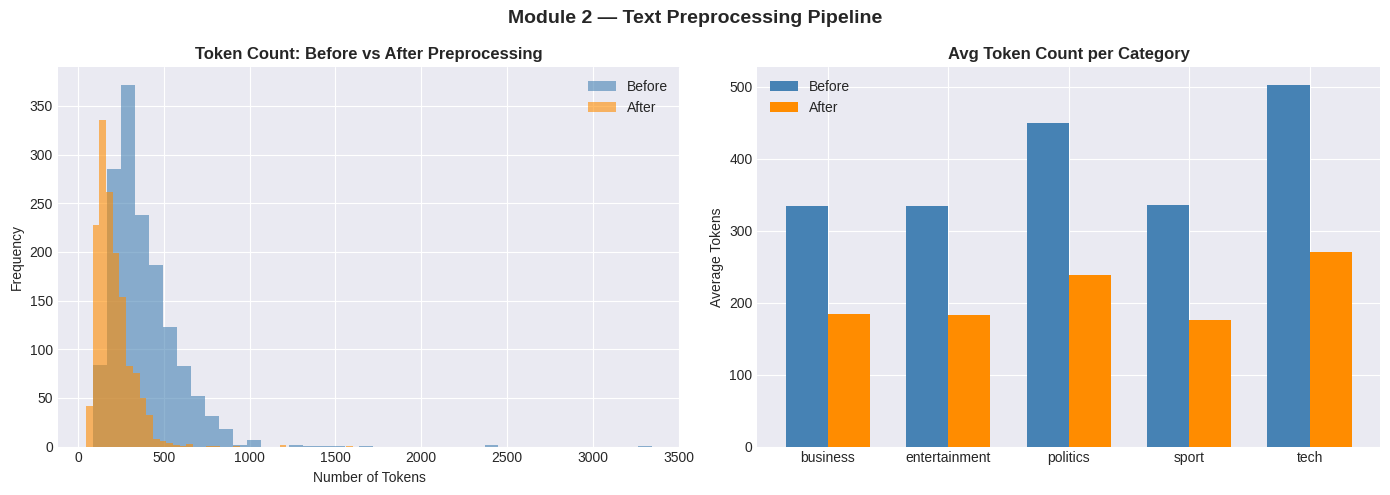

✅ Module 2 Complete!


In [8]:
# MODULE 2: Preprocessing Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['tokens_before'], bins=40, alpha=0.6, label='Before', color='steelblue')
axes[0].hist(df['tokens_after'],  bins=40, alpha=0.6, label='After',  color='darkorange')
axes[0].set_title('Token Count: Before vs After Preprocessing', fontweight='bold')
axes[0].set_xlabel('Number of Tokens')
axes[0].set_ylabel('Frequency')
axes[0].legend()

cat_stats = df.groupby('category')[['tokens_before','tokens_after']].mean()
x = np.arange(len(cat_stats))
w = 0.35
axes[1].bar(x-w/2, cat_stats['tokens_before'], w, label='Before', color='steelblue')
axes[1].bar(x+w/2, cat_stats['tokens_after'],  w, label='After',  color='darkorange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cat_stats.index)
axes[1].set_title('Avg Token Count per Category', fontweight='bold')
axes[1].set_ylabel('Average Tokens')
axes[1].legend()

plt.suptitle('Module 2 — Text Preprocessing Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('module2_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Module 2 Complete!')

---
#  MODULE 3: TF-IDF Feature Extraction and Analysis

In [9]:
# MODULE 3: TF-IDF Vectorization with Parameter Optimization
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    sublinear_tf=True
)
tfidf_matrix = tfidf.fit_transform(df['processed_text'])
feature_names = tfidf.get_feature_names_out()

print('=' * 50)
print('      TF-IDF FEATURE EXTRACTION RESULTS')
print('=' * 50)
print(f'  Vocabulary Size : {len(feature_names):,} terms')
print(f'  Matrix Shape    : {tfidf_matrix.shape}')
sparsity = (1 - tfidf_matrix.nnz/(tfidf_matrix.shape[0]*tfidf_matrix.shape[1])) * 100
print(f'  Sparsity        : {sparsity:.1f}%')
print('=' * 50)

# Category-specific term analysis
print('\n Top 10 TF-IDF Terms per Category:')
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
tfidf_df['category'] = df['category'].values
top_terms = {}
for cat in df['category'].unique():
    scores = tfidf_df[tfidf_df['category']==cat].drop('category', axis=1).mean()
    top_terms[cat] = scores.nlargest(10)
    print(f'  [{cat.upper()}]: {list(top_terms[cat].index)}')

      TF-IDF FEATURE EXTRACTION RESULTS
  Vocabulary Size : 5,000 terms
  Matrix Shape    : (1490, 5000)
  Sparsity        : 97.5%

 Top 10 TF-IDF Terms per Category:
  [BUSINESS]: ['said', 'firm', 'company', 'market', 'year', 'share', 'growth', 'economy', 'bank', 'sale']
  [TECH]: ['people', 'user', 'technology', 'said', 'software', 'computer', 'mobile', 'service', 'phone', 'use']
  [POLITICS]: ['labour', 'election', 'party', 'government', 'minister', 'blair', 'said', 'tory', 'would', 'say']
  [SPORT]: ['game', 'win', 'player', 'match', 'champion', 'said', 'england', 'cup', 'team', 'side']
  [ENTERTAINMENT]: ['film', 'award', 'star', 'show', 'actor', 'best', 'music', 'year', 'said', 'band']


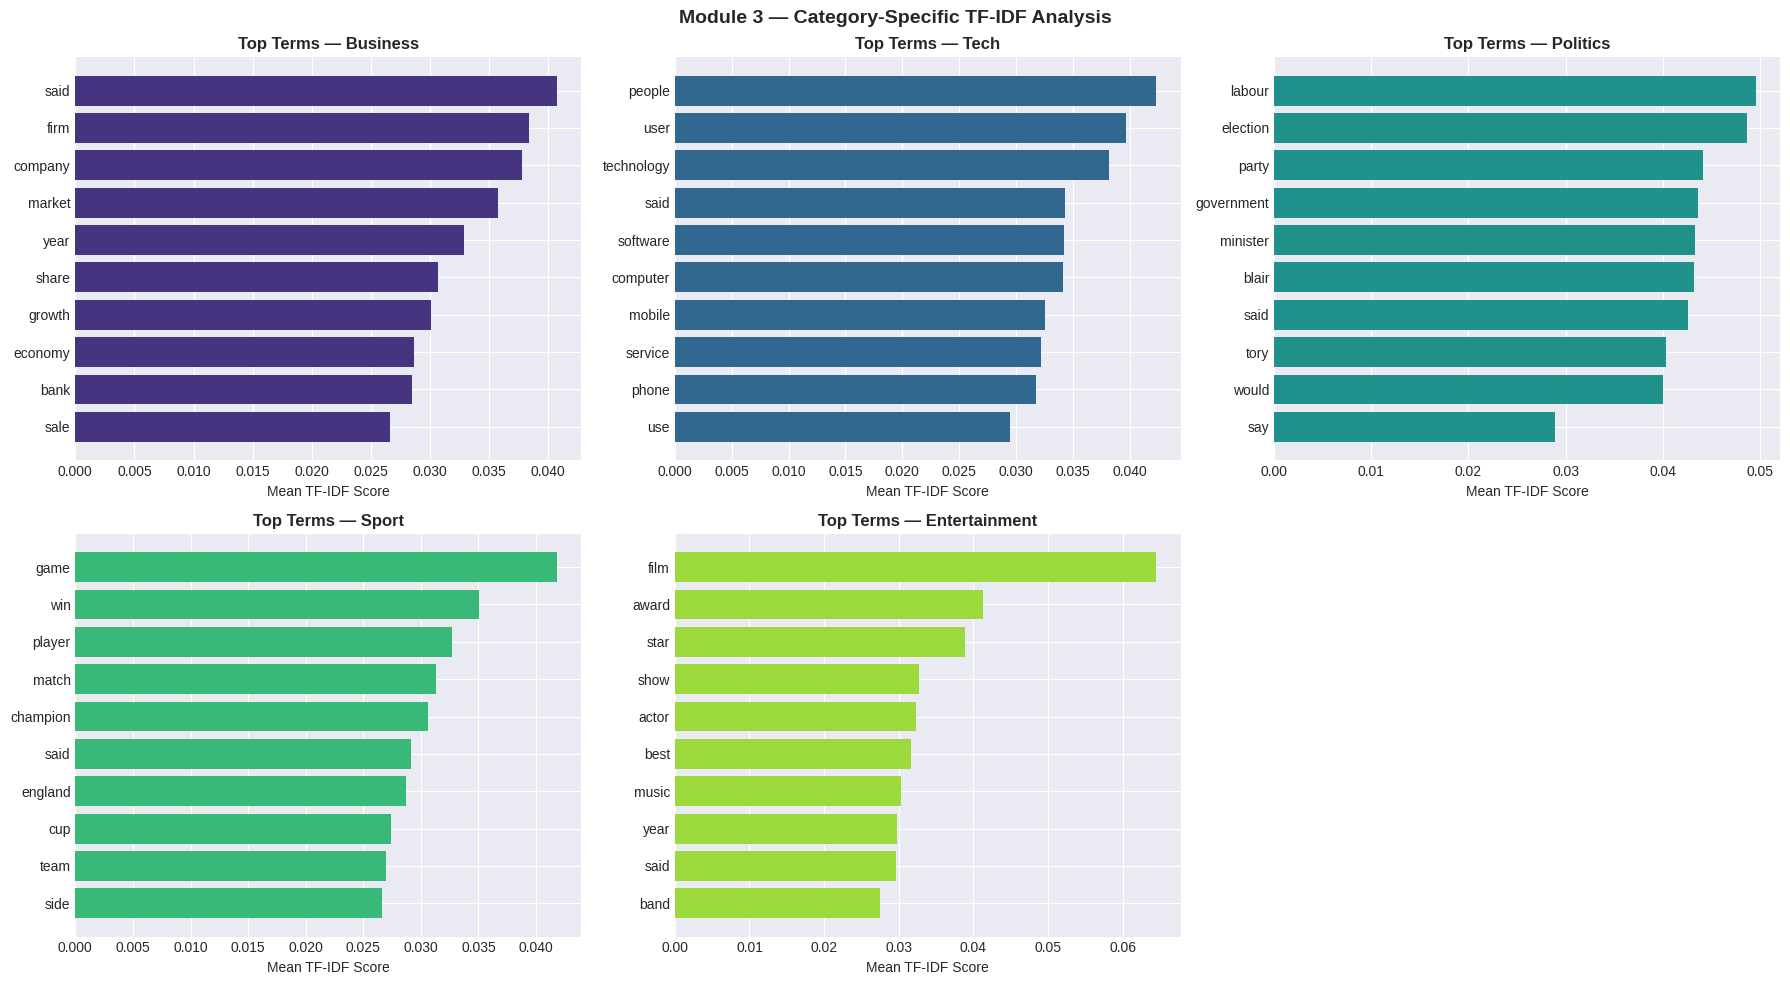

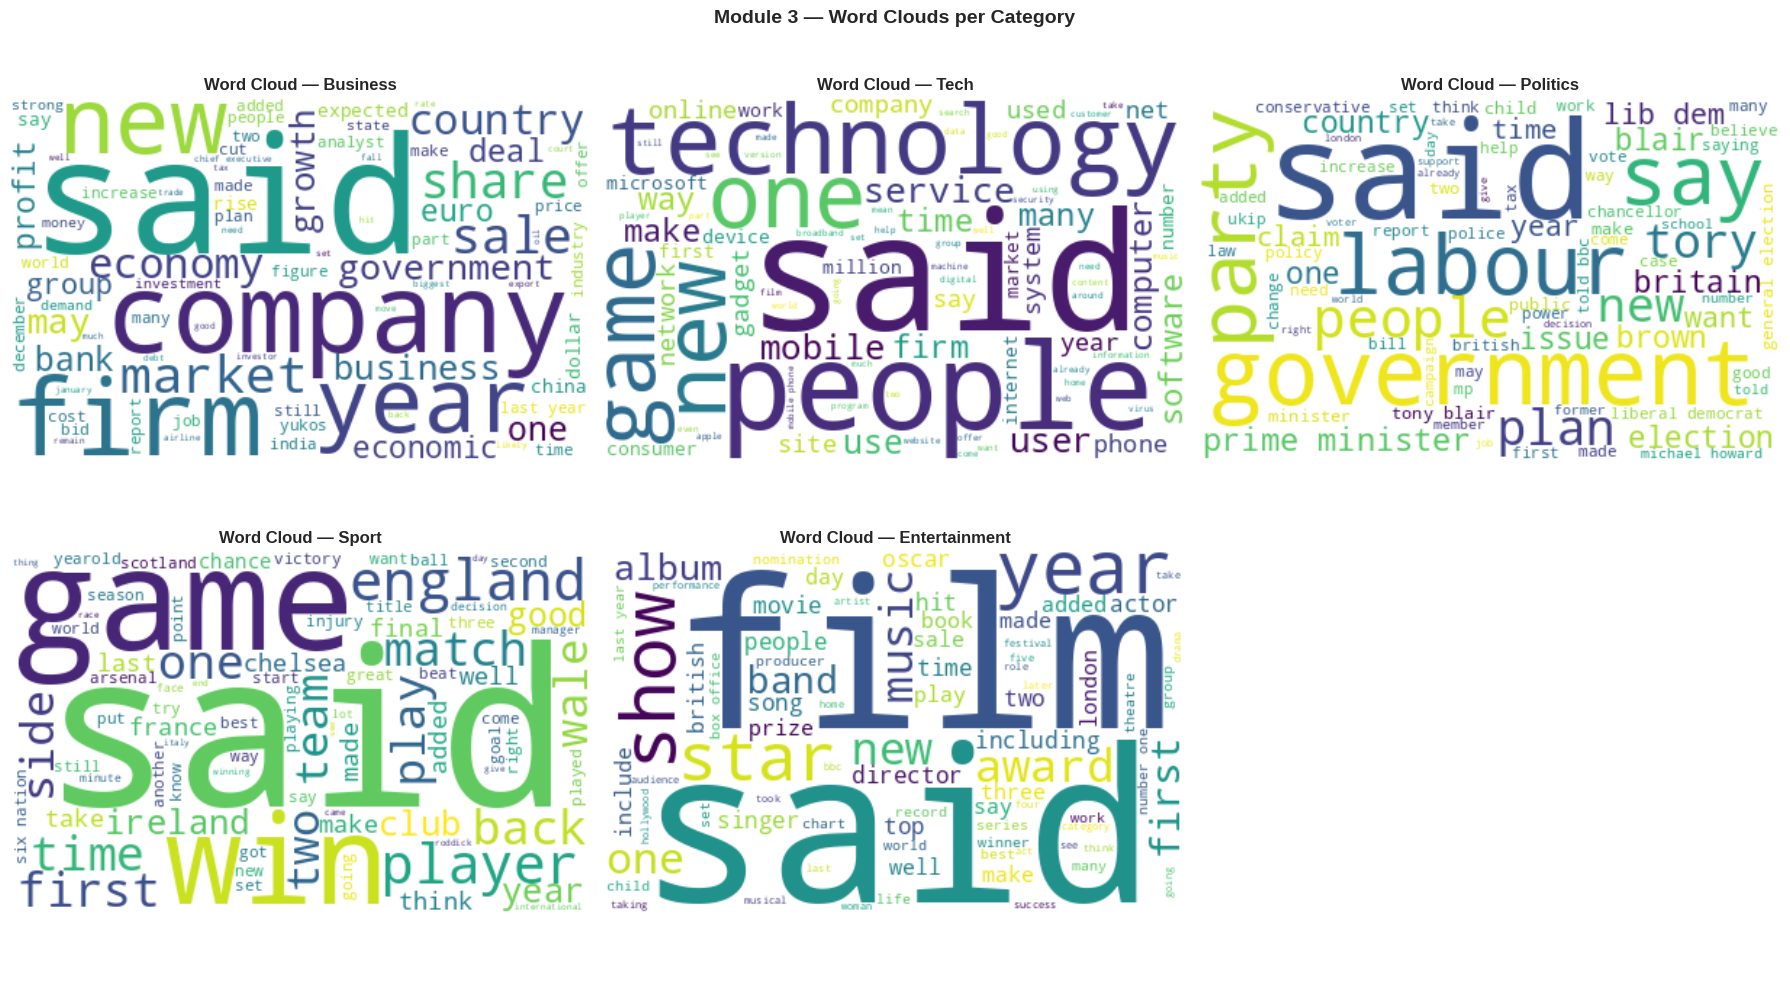

✅ Module 3 Complete!


In [10]:

# MODULE 3: TF-IDF Visualizations — Bar charts + Word Clouds
categories = list(df['category'].unique())
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(categories)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, cat in enumerate(categories):
    terms = top_terms[cat]
    axes[i].barh(terms.index[::-1], terms.values[::-1], color=colors[i])
    axes[i].set_title(f'Top Terms — {cat.capitalize()}', fontweight='bold')
    axes[i].set_xlabel('Mean TF-IDF Score')
for j in range(len(categories), 6):
    axes[j].axis('off')
plt.suptitle('Module 3 — Category-Specific TF-IDF Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('module3_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, cat in enumerate(categories):
    cat_text = ' '.join(df[df['category']==cat]['processed_text'])
    wc = WordCloud(width=400, height=250, background_color='white',
                   max_words=80, colormap='viridis').generate(cat_text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Word Cloud — {cat.capitalize()}', fontweight='bold')
    axes[i].axis('off')
for j in range(len(categories), 6):
    axes[j].axis('off')
plt.suptitle('Module 3 — Word Clouds per Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('module3_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Module 3 Complete!')

---
#  MODULE 4: Part-of-Speech Pattern Analysis

In [11]:
# MODULE 4: POS Tagging & Grammatical Pattern Extraction
POS_MAP = {
    'NN':'Noun','NNS':'Noun','NNP':'ProperNoun','NNPS':'ProperNoun',
    'VB':'Verb','VBD':'Verb','VBG':'Verb','VBN':'Verb','VBP':'Verb','VBZ':'Verb',
    'JJ':'Adjective','JJR':'Adjective','JJS':'Adjective',
    'RB':'Adverb','RBR':'Adverb','RBS':'Adverb',
    'IN':'Preposition','DT':'Determiner','CC':'Conjunction'
}

def get_pos_distribution(text):
    tokens = word_tokenize(text[:600])
    tags = pos_tag(tokens)
    counts = {}
    for _, tag in tags:
        label = POS_MAP.get(tag, 'Other')
        counts[label] = counts.get(label, 0) + 1
    return counts

print(' Running POS tagging (150 articles per category)...')
pos_sample = df.groupby('category').apply(
    lambda x: x.sample(min(len(x), 150), random_state=42)
).reset_index(drop=True)
pos_sample['pos_dist'] = pos_sample['content'].apply(get_pos_distribution)

pos_summary = {}
for cat in pos_sample['category'].unique():
    combined = {}
    for d in pos_sample[pos_sample['category']==cat]['pos_dist']:
        for k, v in d.items():
            combined[k] = combined.get(k, 0) + v
    total = sum(combined.values())
    pos_summary[cat] = {k: round(v/total*100, 2) for k, v in combined.items()}

pos_df = pd.DataFrame(pos_summary).T.fillna(0)
show_cols = [c for c in ['Noun','Verb','Adjective','Adverb','ProperNoun','Preposition'] if c in pos_df.columns]
print(' POS tagging complete!')
print('\n POS Distribution (%) — Writing Style Differences:')
print(pos_df[show_cols].round(2).to_string())

 Running POS tagging (150 articles per category)...
 POS tagging complete!

 POS Distribution (%) — Writing Style Differences:
                Noun   Verb  Adjective  Adverb  ProperNoun  Preposition
business       32.02  15.86      10.12    2.24        0.19        11.76
entertainment  33.23  16.19      10.70    2.26        0.09        11.07
politics       30.29  18.89      10.41    2.77        0.08        10.36
sport          29.03  17.18      11.91    3.07        0.04        11.17
tech           30.10  17.74      10.54    2.85        0.10        11.37


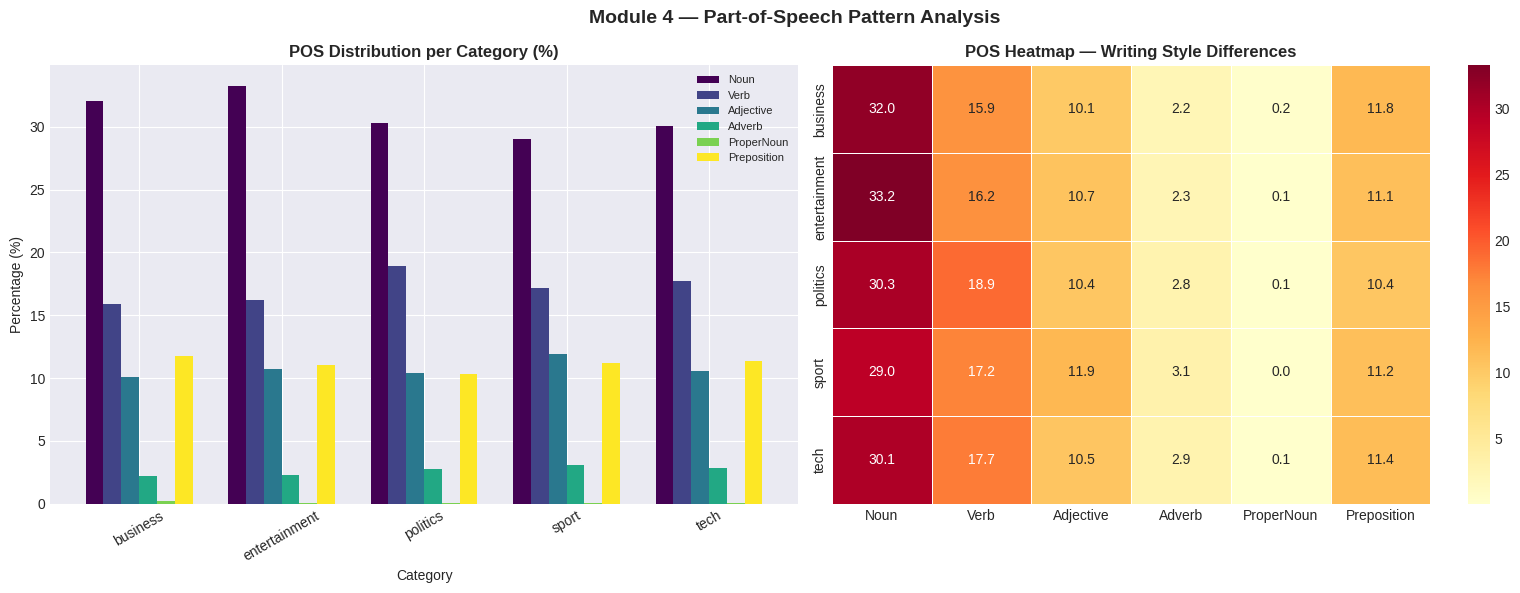

✅ Module 4 Complete!


In [12]:
# MODULE 4: POS Visualization
pos_plot = pos_df[show_cols].fillna(0)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pos_plot.plot(kind='bar', ax=axes[0], colormap='viridis', width=0.75)
axes[0].set_title('POS Distribution per Category (%)', fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(pos_plot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1], linewidths=0.5)
axes[1].set_title('POS Heatmap — Writing Style Differences', fontweight='bold')

plt.suptitle('Module 4 — Part-of-Speech Pattern Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('module4_pos.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Module 4 Complete!')

---
#  MODULE 5: Syntax Parsing and Semantic Analysis

In [13]:
# MODULE 5: Dependency Parsing & Syntactic Feature Engineering
def extract_syntactic_features(text):
    """
    Syntactic feature engineering using spaCy dependency parser:
    - Sentence count and average sentence length
    - Subject-Verb-Object (SVO) triple extraction
    - Noun chunk count for semantic role identification
    """
    doc = nlp(str(text)[:1000])
    sentences = list(doc.sents)
    sent_count = len(sentences)
    avg_sent_len = np.mean([len(s) for s in sentences]) if sentences else 0

    svo_triples = []
    for token in doc:
        if token.dep_ == 'nsubj' and token.head.pos_ == 'VERB':
            objs = [c.text for c in token.head.children if c.dep_ in ('dobj','attr','prep')]
            if objs:
                svo_triples.append((token.text, token.head.text, objs[0]))

    return {
        'sent_count'  : sent_count,
        'avg_sent_len': round(avg_sent_len, 2),
        'svo_count'   : len(svo_triples),
        'noun_chunks' : len(list(doc.noun_chunks)),
        'svo_triples' : svo_triples[:3]
    }

print(' Running dependency parsing (50 articles per category)...')
syn_sample = df.groupby('category').apply(
    lambda x: x.sample(min(len(x), 50), random_state=42)
).reset_index(drop=True)
syn_results = syn_sample['content'].apply(extract_syntactic_features)
syn_df = pd.DataFrame(syn_results.tolist())
syn_df['category'] = syn_sample['category'].values

print(' Dependency parsing complete!')
print('\n Average Syntactic Features per Category:')
print(syn_df.groupby('category')[['sent_count','avg_sent_len','svo_count','noun_chunks']]
      .mean().round(2).to_string())

print('\n Sample SVO Triples:')
for _, row in syn_sample.head(4).iterrows():
    r = extract_syntactic_features(row['content'])
    if r['svo_triples']:
        print(f"  [{row['category'].upper()}] {r['svo_triples']}")

 Running dependency parsing (50 articles per category)...
 Dependency parsing complete!

 Average Syntactic Features per Category:
               sent_count  avg_sent_len  svo_count  noun_chunks
category                                                       
business             8.46         23.39       6.44        43.76
entertainment        8.54         24.01       7.48        46.04
politics             8.34         23.46       6.66        45.18
sport                9.40         22.12       8.26        45.76
tech                 8.30         24.32       7.12        46.16

 Sample SVO Triples:
  [BUSINESS] [('nasdaq', 'planning', 'sale'), ('observers', 'see', 'this'), ('nasdaq', 'poured', 'water')]
  [BUSINESS] [('deccan', 'ordered', 'planes'), ('airline', 'expands', 'in'), ('potential', 'attracted', 'attention')]
  [BUSINESS] [('inches', 'open', 'door'), ('abdullah', 'told', 'departments'), ('gosaibi', 'caused', 'uproar')]
  [BUSINESS] [('prices', 'surged', 'above'), ('watchdog', 'rai

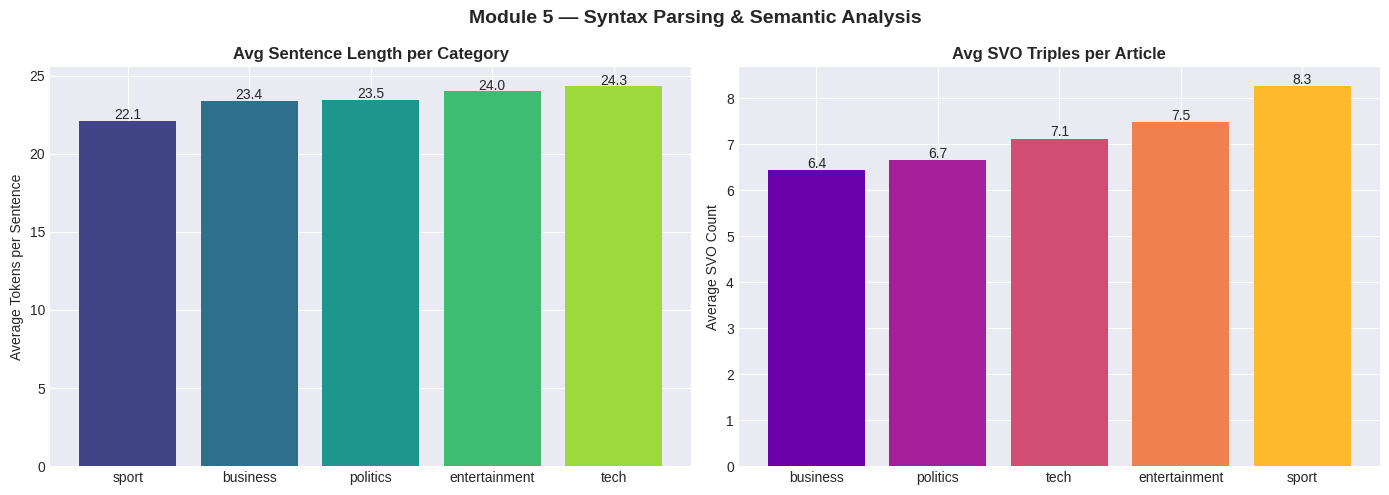

✅ Module 5 Complete!


In [14]:
# MODULE 5: Syntax Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.85, df['category'].nunique()))

sent_len = syn_df.groupby('category')['avg_sent_len'].mean().sort_values()
bars = axes[0].bar(sent_len.index, sent_len.values, color=colors)
axes[0].set_title('Avg Sentence Length per Category', fontweight='bold')
axes[0].set_ylabel('Average Tokens per Sentence')
for bar, val in zip(bars, sent_len.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{val:.1f}', ha='center', fontsize=10)

svo = syn_df.groupby('category')['svo_count'].mean().sort_values()
bars2 = axes[1].bar(svo.index, svo.values,
                    color=plt.cm.plasma(np.linspace(0.2, 0.85, len(svo))))
axes[1].set_title('Avg SVO Triples per Article', fontweight='bold')
axes[1].set_ylabel('Average SVO Count')
for bar, val in zip(bars2, svo.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.1f}', ha='center', fontsize=10)

plt.suptitle('Module 5 — Syntax Parsing & Semantic Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('module5_syntax.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Module 5 Complete!')

---
# MODULE 6: Sentiment and Emotion Analysis

In [15]:
# MODULE 6: Article-Level Sentiment Classification
def analyze_sentiment(text):
    blob = TextBlob(str(text)[:1000])
    pol  = blob.sentiment.polarity
    subj = blob.sentiment.subjectivity
    label = 'Positive' if pol > 0.1 else ('Negative' if pol < -0.1 else 'Neutral')
    return pd.Series({'polarity': round(pol,4), 'subjectivity': round(subj,4), 'sentiment_label': label})

print(' Analyzing sentiment for all articles...')
df = pd.concat([df, df['content'].apply(analyze_sentiment)], axis=1)
print('✅ Sentiment analysis complete!')

print('\n💬 Average Polarity & Subjectivity per Category:')
print(df.groupby('category')[['polarity','subjectivity']].mean().round(4).to_string())
print('\n Sentiment Label Distribution:')
sent_dist = df.groupby(['category','sentiment_label']).size().unstack(fill_value=0)
print(sent_dist.to_string())
print(f'\n Most positive category : {df.groupby("category")["polarity"].mean().idxmax()}')
print(f' Most negative category : {df.groupby("category")["polarity"].mean().idxmin()}')
print(f' Most objective category: {df.groupby("category")["subjectivity"].mean().idxmin()}')

 Analyzing sentiment for all articles...
✅ Sentiment analysis complete!

💬 Average Polarity & Subjectivity per Category:
               polarity  subjectivity
category                             
business         0.0502        0.3759
entertainment    0.1441        0.3807
politics         0.0634        0.3913
sport            0.1046        0.4086
tech             0.1060        0.4265

 Sentiment Label Distribution:
sentiment_label  Negative  Neutral  Positive
category                                    
business               20      230        86
entertainment           9       93       171
politics               18      155       101
sport                  15      150       181
tech                    8      120       133

 Most positive category : entertainment
 Most negative category : business
 Most objective category: business


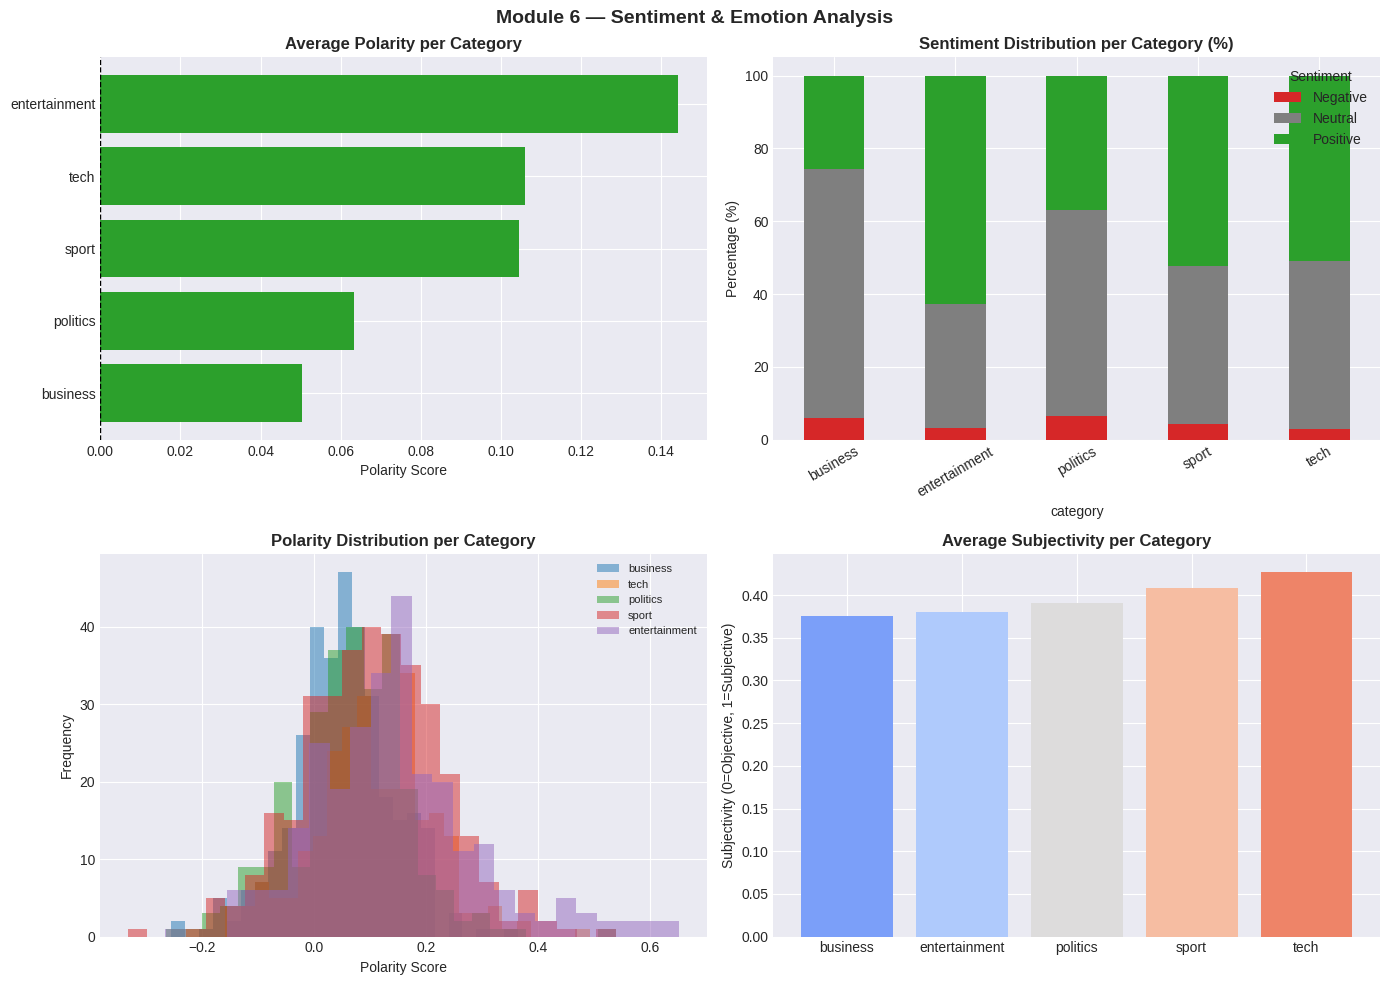

✅ Module 6 Complete!


In [16]:
# MODULE 6: Sentiment Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pol = df.groupby('category')['polarity'].mean().sort_values()
bar_colors = ['#d62728' if v < 0 else '#2ca02c' for v in pol.values]
axes[0,0].barh(pol.index, pol.values, color=bar_colors)
axes[0,0].axvline(x=0, color='black', linewidth=1, linestyle='--')
axes[0,0].set_title('Average Polarity per Category', fontweight='bold')
axes[0,0].set_xlabel('Polarity Score')

sent_pct = sent_dist.div(sent_dist.sum(axis=1), axis=0) * 100
col_order = [c for c in ['Negative','Neutral','Positive'] if c in sent_pct.columns]
color_map = {'Negative':'#d62728','Neutral':'#7f7f7f','Positive':'#2ca02c'}
sent_pct[col_order].plot(kind='bar', stacked=True, ax=axes[0,1],
    color=[color_map[c] for c in col_order])
axes[0,1].set_title('Sentiment Distribution per Category (%)', fontweight='bold')
axes[0,1].set_ylabel('Percentage (%)')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].legend(title='Sentiment')

for cat in df['category'].unique():
    axes[1,0].hist(df[df['category']==cat]['polarity'], bins=25, alpha=0.5, label=cat)
axes[1,0].set_title('Polarity Distribution per Category', fontweight='bold')
axes[1,0].set_xlabel('Polarity Score')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend(fontsize=8)

subj = df.groupby('category')['subjectivity'].mean().sort_values()
axes[1,1].bar(subj.index, subj.values,
              color=plt.cm.coolwarm(np.linspace(0.2, 0.8, len(subj))))
axes[1,1].set_title('Average Subjectivity per Category', fontweight='bold')
axes[1,1].set_ylabel('Subjectivity (0=Objective, 1=Subjective)')

plt.suptitle('Module 6 — Sentiment & Emotion Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('module6_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Module 6 Complete!')

---
# MODULE 7: Multi-Class Text Classification System

In [17]:
# MODULE 7: Multiple Classification Algorithms — Comparison & Evaluation
X = df['processed_text']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'  Training : {len(X_train)} | Testing : {len(X_test)}')
print(f'  Categories: {sorted(y.unique().tolist())}')

classifiers = {
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Linear SVM'         : LinearSVC(C=1.0, max_iter=2000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}
print('\n⏳ Training all classifiers...')
print('-' * 60)
print(f'{"Model":<25} {"Accuracy":>10} {"F1 Score":>10}')
print('-' * 60)

for name, clf in classifiers.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)),
        ('clf', clf)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'pipeline': pipe, 'y_pred': y_pred, 'accuracy': acc, 'f1_score': f1}
    print(f'  {name:<23} {acc:>10.4f} {f1:>10.4f}')

print('-' * 60)
best_name = max(results, key=lambda k: results[k]['accuracy'])
print(f'\n Best Model: {best_name} ({results[best_name]["accuracy"]:.4f})')
print(f'\n Classification Report — {best_name}:')
print(classification_report(y_test, results[best_name]['y_pred'], target_names=sorted(y.unique())))

  Training : 1192 | Testing : 298
  Categories: ['business', 'entertainment', 'politics', 'sport', 'tech']

⏳ Training all classifiers...
------------------------------------------------------------
Model                       Accuracy   F1 Score
------------------------------------------------------------
  Naive Bayes                 0.9765     0.9765
  Logistic Regression         0.9732     0.9731
  Linear SVM                  0.9765     0.9763
  Random Forest               0.9597     0.9598
------------------------------------------------------------

 Best Model: Naive Bayes (0.9765)

 Classification Report — Naive Bayes:
               precision    recall  f1-score   support

     business       0.98      0.97      0.98        67
entertainment       1.00      0.98      0.99        55
     politics       0.96      0.95      0.95        55
        sport       0.99      1.00      0.99        69
         tech       0.94      0.98      0.96        52

     accuracy                    

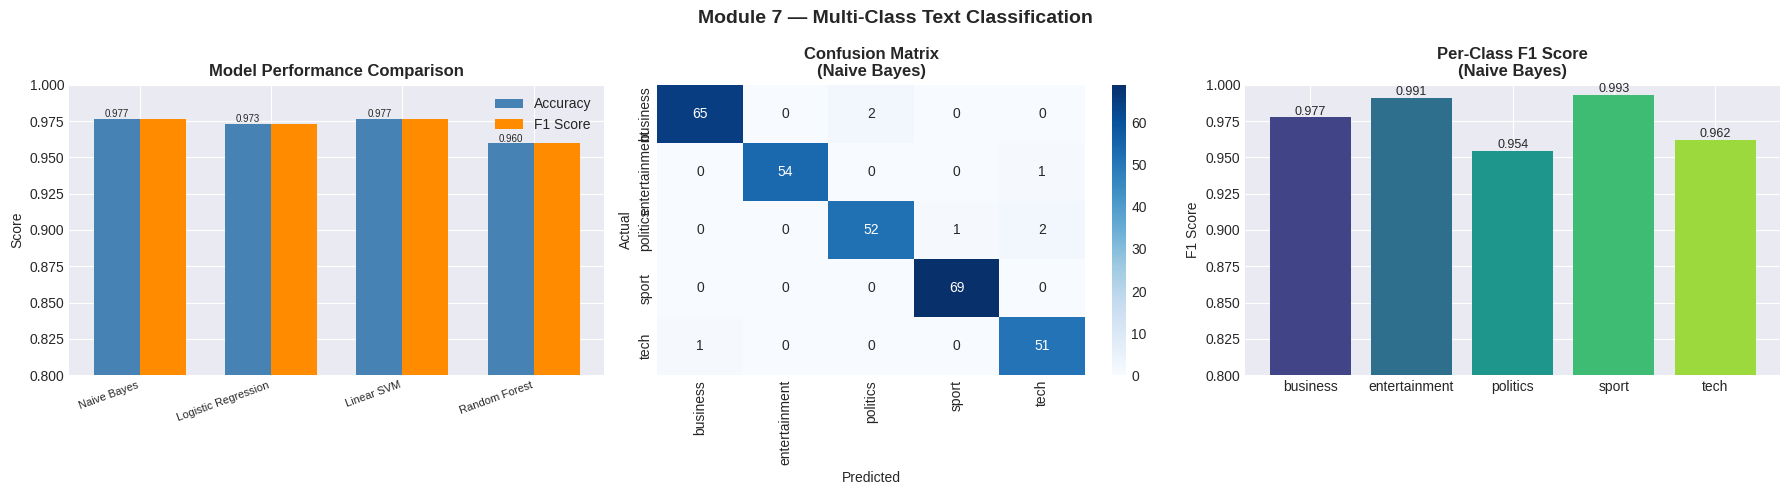

✅ Module 7 Complete!


In [18]:
# MODULE 7: Classification Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = list(results.keys())
accs = [results[m]['accuracy'] for m in model_names]
f1s  = [results[m]['f1_score']  for m in model_names]
x = np.arange(len(model_names))
w = 0.35
b1 = axes[0].bar(x-w/2, accs, w, label='Accuracy', color='steelblue')
b2 = axes[0].bar(x+w/2, f1s,  w, label='F1 Score',  color='darkorange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=20, ha='right', fontsize=8)
axes[0].set_ylim(0.8, 1.0)
axes[0].set_title('Model Performance Comparison', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].legend()
for bar in b1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                 f'{bar.get_height():.3f}', ha='center', fontsize=7)

cm = confusion_matrix(y_test, results[best_name]['y_pred'], labels=sorted(y.unique()))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()), cmap='Blues', ax=axes[1])
axes[1].set_title(f'Confusion Matrix\n({best_name})', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

per_class = f1_score(y_test, results[best_name]['y_pred'], average=None, labels=sorted(y.unique()))
axes[2].bar(sorted(y.unique()), per_class,
            color=plt.cm.viridis(np.linspace(0.2, 0.85, len(per_class))))
axes[2].set_title(f'Per-Class F1 Score\n({best_name})', fontweight='bold')
axes[2].set_ylabel('F1 Score')
axes[2].set_ylim(0.8, 1.0)
for i, v in enumerate(per_class):
    axes[2].text(i, v+0.002, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Module 7 — Multi-Class Text Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('module7_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Module 7 Complete!')

---
#  MODULE 8: Named Entity Recognition and Analysis

In [19]:
# MODULE 8: NER — Entity Extraction & Classification
ENTITY_TYPES = ['PERSON', 'ORG', 'GPE', 'DATE', 'MONEY', 'NORP', 'PRODUCT']

def extract_entities(text):
    """
    Extract named entities using spaCy:
    PERSON  — people, ORG — organizations
    GPE     — locations, DATE — dates
    MONEY   — monetary values, NORP — nationalities
    """
    doc = nlp(str(text)[:1200])
    entities = {e: [] for e in ENTITY_TYPES}
    for ent in doc.ents:
        if ent.label_ in ENTITY_TYPES:
            entities[ent.label_].append(ent.text.strip())
    return entities

print('Running NER (80 articles per category)...')
ner_sample = df.groupby('category').apply(
    lambda x: x.sample(min(len(x), 80), random_state=42)
).reset_index(drop=True)
ner_sample['entities'] = ner_sample['content'].apply(extract_entities)
for e in ENTITY_TYPES:
    ner_sample[f'count_{e}'] = ner_sample['entities'].apply(lambda x: len(x.get(e,[])))

count_cols = [f'count_{e}' for e in ENTITY_TYPES]
print(' NER complete!')
print('\n Avg Entity Counts per Category:')
summary = ner_sample.groupby('category')[count_cols].mean().round(2)
summary.columns = ENTITY_TYPES
print(summary.to_string())

all_persons = [p for ents in ner_sample['entities'] for p in ents['PERSON']]
all_orgs    = [o for ents in ner_sample['entities'] for o in ents['ORG']]
all_gpe     = [g for ents in ner_sample['entities'] for g in ents['GPE']]
print('\n Top 10 PERSONS:', Counter(all_persons).most_common(10))
print(' Top 10 ORGS   :', Counter(all_orgs).most_common(10))
print(' Top 10 GPE    :', Counter(all_gpe).most_common(10))

Running NER (80 articles per category)...
 NER complete!

 Avg Entity Counts per Category:
               PERSON   ORG   GPE  DATE  MONEY  NORP  PRODUCT
category                                                     
business         1.58  2.22  2.84  4.89   1.64  1.39     0.04
entertainment    5.32  1.68  2.04  4.30   0.88  1.08     0.04
politics         3.86  1.10  1.91  2.39   0.28  1.12     0.00
sport            4.05  1.30  3.22  3.79   0.14  1.49     0.01
tech             1.02  1.76  1.18  2.84   0.40  0.62     0.02

 Top 10 PERSONS: [('blair', 33), ('tony blair', 20), ('eu', 12), ('michael howard', 11), ('gordon brown', 10), ('sullivan', 9), ('bush', 9), ('harry potter', 9), ('howard', 8), ('johnson', 8)]
 Top 10 ORGS   : [('bbc', 44), ('microsoft', 22), ('fbi', 18), ('sony', 11), ('the bbc news', 10), ('gm', 8), ('bez', 8), ('yahoo', 8), ('the european union', 7), ('viacom', 7)]
 Top 10 GPE    : [('uk', 102), ('us', 72), ('london', 49), ('france', 39), ('england', 33), ('china', 3

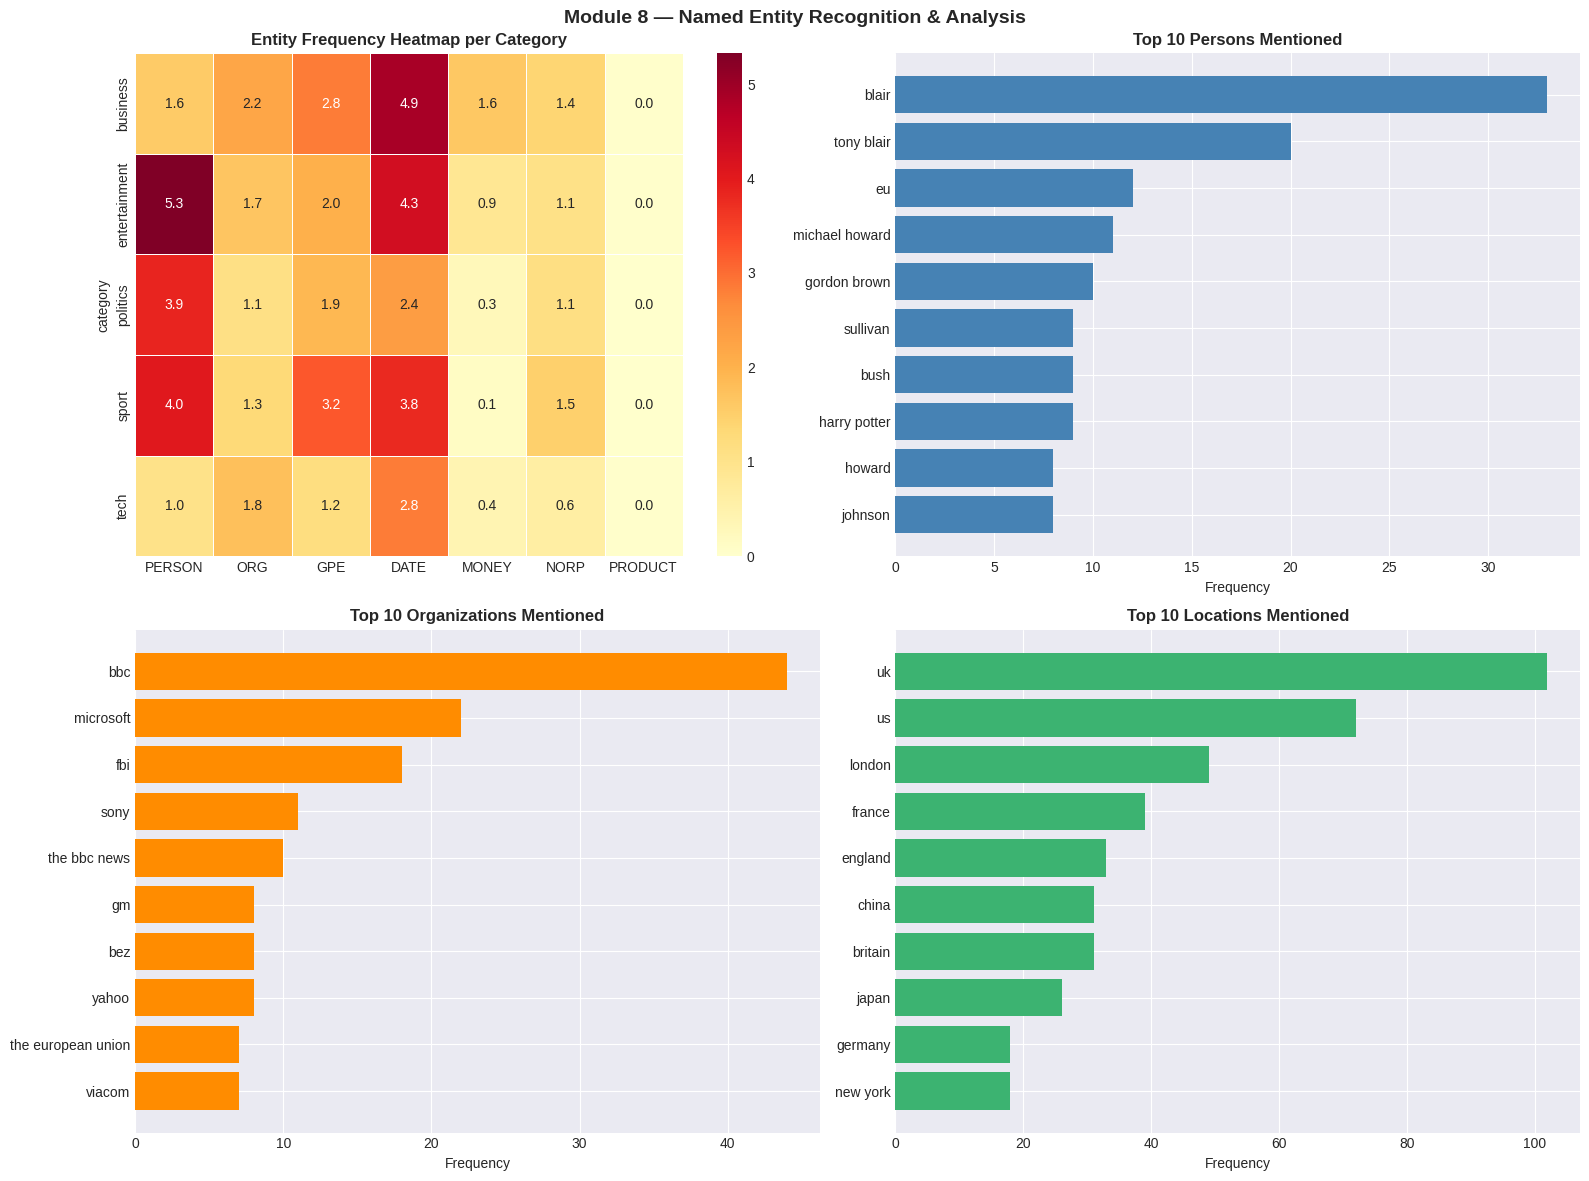

✅ Module 8 Complete!


In [20]:
# MODULE 8: NER Visualization — Cross-Category Entity Pattern Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

entity_heat = ner_sample.groupby('category')[count_cols].mean()
entity_heat.columns = ENTITY_TYPES
sns.heatmap(entity_heat, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0,0], linewidths=0.5)
axes[0,0].set_title('Entity Frequency Heatmap per Category', fontweight='bold')

top_p = Counter(all_persons).most_common(10)
if top_p:
    names, counts = zip(*top_p)
    axes[0,1].barh(list(names)[::-1], list(counts)[::-1], color='steelblue')
    axes[0,1].set_title('Top 10 Persons Mentioned', fontweight='bold')
    axes[0,1].set_xlabel('Frequency')

top_o = Counter(all_orgs).most_common(10)
if top_o:
    orgs, oc = zip(*top_o)
    axes[1,0].barh(list(orgs)[::-1], list(oc)[::-1], color='darkorange')
    axes[1,0].set_title('Top 10 Organizations Mentioned', fontweight='bold')
    axes[1,0].set_xlabel('Frequency')

top_g = Counter(all_gpe).most_common(10)
if top_g:
    locs, lc = zip(*top_g)
    axes[1,1].barh(list(locs)[::-1], list(lc)[::-1], color='mediumseagreen')
    axes[1,1].set_title('Top 10 Locations Mentioned', fontweight='bold')
    axes[1,1].set_xlabel('Frequency')

plt.suptitle('Module 8 — Named Entity Recognition & Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('module8_ner.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Module 8 Complete!')

---
# Live NewsBot Demo — Full Pipeline on New Articles


In [21]:
# LIVE DEMO: Complete pipeline on brand new articles
best_pipeline = results[best_name]['pipeline']

def newsbot_analyze(article_text):
    """Full NewsBot pipeline: preprocess → classify → sentiment → NER"""
    print('\n' + '='*62)
    print('            NEWSBOT INTELLIGENCE ANALYSIS')
    print('='*62)
    print(f' Input: {article_text.strip()[:180]}...')
    processed = preprocess_text(article_text)
    category  = best_pipeline.predict([processed])[0]
    print(f'\n Category   : {category.upper()} (model: {best_name})')
    blob  = TextBlob(article_text[:1000])
    pol   = blob.sentiment.polarity
    subj  = blob.sentiment.subjectivity
    label = 'Positive' if pol > 0.1 else ('Negative' if pol < -0.1 else 'Neutral')
    print(f' Sentiment  : {label} (polarity={pol:.3f}, subjectivity={subj:.3f})')
    doc = nlp(article_text[:1200])
    ents = {}
    for ent in doc.ents:
        if ent.label_ in ENTITY_TYPES:
            ents.setdefault(ent.label_, []).append(ent.text)
    print('  Entities   :')
    for etype, vals in ents.items():
        print(f'     {etype:<10}: {list(dict.fromkeys(vals))[:5]}')
    print('='*62)

# Test with 3 new articles (NOT from training data)
newsbot_analyze("""
Apple Inc reported record quarterly revenues of 120 billion dollars driven by strong iPhone
sales in the United States and China. CEO Tim Cook announced major investments in artificial
intelligence. The stock rose 5 percent on Wall Street following the announcement on Monday.
""")

newsbot_analyze("""
Manchester United defeated Arsenal 3-1 at Old Trafford on Saturday. Marcus Rashford scored
twice and Bruno Fernandes added a third. Manager Erik ten Hag praised the performance
calling it the best display of the season.
""")

newsbot_analyze("""
The United Nations held an emergency meeting in New York to address tensions between Russia
and Ukraine. Secretary-General Antonio Guterres called for diplomatic dialogue. The United
States and European Union announced new economic sanctions.
""")

print('\n✅ Live Demo Complete!')


            NEWSBOT INTELLIGENCE ANALYSIS
 Input: Apple Inc reported record quarterly revenues of 120 billion dollars driven by strong iPhone
sales in the United States and China. CEO Tim Cook announced major investments in artifi...

 Category   : BUSINESS (model: Naive Bayes)
 Sentiment  : Neutral (polarity=0.099, subjectivity=0.657)
  Entities   :
     ORG       : ['Apple Inc']
     DATE      : ['quarterly', 'Monday']
     MONEY     : ['120 billion dollars']
     GPE       : ['the United States', 'China']
     PERSON    : ['Tim Cook']

            NEWSBOT INTELLIGENCE ANALYSIS
 Input: Manchester United defeated Arsenal 3-1 at Old Trafford on Saturday. Marcus Rashford scored
twice and Bruno Fernandes added a third. Manager Erik ten Hag praised the performance
cal...

 Category   : SPORT (model: Naive Bayes)
 Sentiment  : Positive (polarity=0.275, subjectivity=0.125)
  Entities   :
     PERSON    : ['Manchester United', 'Marcus Rashford', 'Bruno Fernandes', 'Erik']
     ORG       : [

---
# 📈 Business Insights Summary

In [22]:
# BUSINESS INSIGHTS SUMMARY
print('=' * 65)
print('         NEWSBOT — BUSINESS INSIGHTS SUMMARY')
print('=' * 65)
print(f"""
🔹 DATASET
   Source                  : BBC News Classification (Kaggle)
   Total articles analyzed : {len(df)}
   Categories              : {sorted(df['category'].unique().tolist())}

🔹 CLASSIFICATION PERFORMANCE
   Best model              : {best_name}
   Accuracy                : {results[best_name]['accuracy']:.2%}
   F1 Score (weighted)     : {results[best_name]['f1_score']:.2%}
   Business impact         : Automates article routing and tagging at scale

🔹 SENTIMENT INSIGHTS
   Most positive category  : {df.groupby('category')['polarity'].mean().idxmax().capitalize()}
   Most negative category  : {df.groupby('category')['polarity'].mean().idxmin().capitalize()}
   Most objective writing  : {df.groupby('category')['subjectivity'].mean().idxmin().capitalize()}
   Business impact         : Real-time brand and market sentiment monitoring

🔹 NLP FEATURES EXTRACTED
   TF-IDF vocabulary       : 5,000 features (unigrams + bigrams)
   Entity types tracked    : PERSON, ORG, GPE, DATE, MONEY, NORP
   POS patterns analyzed   : Nouns, Verbs, Adjectives, Adverbs, ProperNouns
   SVO triples extracted   : Subject-Verb-Object relationship mapping
   Business impact         : Competitive intelligence and entity tracking

🔹 SYSTEM CAPABILITIES
   Classifies any new English article in real-time
   Extracts key entities: people, organizations, locations, dates
   Analyzes sentiment tone and objectivity per article
   Identifies writing style differences across categories
   Scalable to any English-language news source
""")
print('=' * 65)
print('✅ NewsBot Intelligence System — ALL 8 MODULES COMPLETE!')

         NEWSBOT — BUSINESS INSIGHTS SUMMARY

🔹 DATASET
   Source                  : BBC News Classification (Kaggle)
   Total articles analyzed : 1490
   Categories              : ['business', 'entertainment', 'politics', 'sport', 'tech']

🔹 CLASSIFICATION PERFORMANCE
   Best model              : Naive Bayes
   Accuracy                : 97.65%
   F1 Score (weighted)     : 97.65%
   Business impact         : Automates article routing and tagging at scale

🔹 SENTIMENT INSIGHTS
   Most positive category  : Entertainment
   Most negative category  : Business
   Most objective writing  : Business
   Business impact         : Real-time brand and market sentiment monitoring

🔹 NLP FEATURES EXTRACTED
   TF-IDF vocabulary       : 5,000 features (unigrams + bigrams)
   Entity types tracked    : PERSON, ORG, GPE, DATE, MONEY, NORP
   POS patterns analyzed   : Nouns, Verbs, Adjectives, Adverbs, ProperNouns
   SVO triples extracted   : Subject-Verb-Object relationship mapping
   Business impact   

In [23]:
import pickle

# Save the best model pipeline
with open('newsbot_model.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

print(f'✅ Model saved! Best model: {best_name}')

# Download it to your computer
from google.colab import files
files.download('newsbot_model.pkl')

✅ Model saved! Best model: Naive Bayes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# Install gradio
!pip install gradio vaderSentiment -q

import gradio as gr
import pickle, re, nltk, spacy
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ── Resources already loaded ──────────────────────────
nlp2  = spacy.load('en_core_web_sm')
sw    = set(stopwords.words('english'))
lem   = WordNetLemmatizer()
vader = SentimentIntensityAnalyzer()

ENTITY_TYPES = ['PERSON', 'ORG', 'GPE', 'DATE', 'MONEY']
CAT_EMOJI    = {
    'business':'💼 Business', 'tech':'💻 Tech',
    'sport':'⚽ Sport', 'politics':'🏛️ Politics',
    'entertainment':'🎬 Entertainment'
}

def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [lem.lemmatize(t) for t in tokens
              if t not in sw and len(t) > 2]
    return ' '.join(tokens)

def get_entities(text):
    doc = nlp2(text[:1200])
    ents = {}
    for ent in doc.ents:
        if ent.label_ in ENTITY_TYPES:
            ents.setdefault(ent.label_, []).append(ent.text.strip())
    return {k: list(dict.fromkeys(v)) for k, v in ents.items()}

# ── Main Analysis Function ────────────────────────────
def analyze_article(article_text):
    if not article_text.strip():
        return "Please paste an article!", "", "", ""

    # Classify
    processed = preprocess(article_text)
    category  = best_pipeline.predict([processed])[0]
    cat_label = CAT_EMOJI.get(category.lower(), category.upper())

    # Sentiment — VADER
    scores = vader.polarity_scores(article_text[:1000])
    pol    = scores['compound']
    if pol >= 0.05:    sent = "😊 Positive"
    elif pol <= -0.05: sent = "😟 Negative"
    else:              sent = "😐 Neutral"
    sentiment_text = f"{sent}\nPolarity: {pol:.3f} | Positive: {scores['pos']:.2f} | Negative: {scores['neg']:.2f} | Neutral: {scores['neu']:.2f}"

    # Entities
    ents = get_entities(article_text)
    ent_text = ""
    if ents:
        for etype, vals in ents.items():
            ent_text += f"{etype}: {', '.join(vals[:5])}\n"
    else:
        ent_text = "No entities detected"

    # Stats
    words = len(article_text.split())
    sents = len([s for s in article_text.split('.') if s.strip()])
    stats = f"Words: {words}\nSentences: {sents}\nTokens (processed): {len(processed.split())}"

    return cat_label, sentiment_text, ent_text.strip(), stats

# ── Gradio UI ─────────────────────────────────────────
with gr.Blocks(theme=gr.themes.Soft(), title="NewsBot Intelligence System") as demo:

    gr.Markdown("""
    # 📰 NewsBot Intelligence System
    ### ITAI2373 — NLP Mid-Term Project | BBC News Dataset
    ---
    """)

    with gr.Row():
        with gr.Column(scale=2):
            article_input = gr.Textbox(
                label="Paste Your News Article Here",
                placeholder="Paste any English news article...",
                lines=12
            )
            with gr.Row():
                clear_btn   = gr.Button("Clear", variant="secondary")
                analyze_btn = gr.Button("Analyze Article", variant="primary")

            gr.Markdown("#### Try a Sample Article:")
            with gr.Row():
                sample1 = gr.Button("💼 Business")
                sample2 = gr.Button("⚽ Sport")
                sample3 = gr.Button("💻 Tech")
                sample4 = gr.Button("🏛️ Politics")

        with gr.Column(scale=2):
            cat_out  = gr.Textbox(label="Category", lines=1)
            sent_out = gr.Textbox(label="Sentiment Analysis", lines=3)
            ent_out  = gr.Textbox(label="Named Entities", lines=6)
            stat_out = gr.Textbox(label="Article Stats", lines=3)

    # Sample articles
    samples = {
        "business": "Apple Inc reported record quarterly revenues of 120 billion dollars driven by strong iPhone sales in the United States and China. CEO Tim Cook announced major investments in artificial intelligence. The stock rose 5 percent on Wall Street following the announcement.",
        "sport": "Manchester United defeated Arsenal 3-1 at Old Trafford on Saturday. Marcus Rashford scored twice and Bruno Fernandes added a third. Manager Erik ten Hag praised the team performance calling it the best display of the season.",
        "tech": "Google announced the launch of its new artificial intelligence model Gemini Ultra which outperforms all existing AI systems on major benchmarks. The model developed at Google DeepMind in London can understand text images and video simultaneously.",
        "politics": "The United Nations held an emergency meeting in New York to address tensions between Russia and Ukraine. Secretary-General Antonio Guterres called for diplomatic dialogue. The United States and European Union announced new economic sanctions."
    }

    # Button actions
    analyze_btn.click(
        fn=analyze_article,
        inputs=article_input,
        outputs=[cat_out, sent_out, ent_out, stat_out]
    )
    clear_btn.click(lambda: ("","","","",""), outputs=[article_input, cat_out, sent_out, ent_out, stat_out])
    sample1.click(lambda: samples["business"], outputs=article_input)
    sample2.click(lambda: samples["sport"],    outputs=article_input)
    sample3.click(lambda: samples["tech"],     outputs=article_input)
    sample4.click(lambda: samples["politics"], outputs=article_input)

# ── Launch ────────────────────────────────────────────
demo.launch(share=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 15.0 MB/s eta 0:00:00
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4019a55b3420f36fe1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
